# Steam Game Reviews
## Notebook 03 — Document embeddings, visualization and representation comparison

Owner: Mitsos · local (Apple Silicon)

Document-level embeddings: one vector per review. Notebook 02 covers the classical
word-level side.

Steps:
1. Setup and data
2. TF-IDF baseline
3. Word2Vec mean-vector baseline
4. Sentence-BERT encoding
5. Representation comparison, plus a controlled re-check
6. t-SNE and PCA
7. Semantic search over reviews
8. Artifacts

Inputs come from notebook 00: the 120,000-review modelling sample and the
game-grouped split indices, so sampling, language filtering and the `model_text`
correction happen once and are shared.

Two design decisions: the split is grouped by game, so no game contributes reviews
to both train and test; and embeddings are L2-normalised at encoding time, so cosine
similarity reduces to a dot product (the semantic search below and notebook 05 rely
on this).


## 1. Setup and data

In [1]:
from pathlib import Path
import gc
import os
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_XET"] = "1"      # avoids the hf_xet download hang on macOS

# Fix all random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_dir(markers=("Data", "data", "outputs"), max_up=4):
    """Locate the project root by walking up from the working directory.

    Portable across macOS, Windows and Linux: no hard-coded absolute paths, and it
    works whether the notebook sits in the project root or in a subfolder.
    """
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents][: max_up + 1]:
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(
        f"Could not locate the project root starting from {start}.\n"
        f"Expected a folder containing one of {markers}.\n"
        "Open the notebook from inside the project folder (the one holding Data/)."
    )

PROJECT_DIR = find_project_dir()

OUTPUT_DIR = PROJECT_DIR / "outputs"
DATA_PATH = OUTPUT_DIR / "data" / "modelling_sample_120k.parquet"
EMBEDDING_DIR = OUTPUT_DIR / "embeddings"
MODEL_DIR = OUTPUT_DIR / "models"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
SPLIT_DIR = OUTPUT_DIR / "splits"
for folder in [EMBEDDING_DIR, MODEL_DIR, TABLE_DIR, FIGURE_DIR, SPLIT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Run notebook 00 first — missing {DATA_PATH}"

# CUDA (Windows/Linux + NVIDIA) -> MPS (Apple Silicon) -> CPU.
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# Load the 120,000-review modelling sample and the game-grouped split indices from notebook 00
df = pd.read_parquet(DATA_PATH).reset_index(drop=True)
train_idx = np.load(SPLIT_DIR / "train_idx.npy")
test_idx = np.load(SPLIT_DIR / "test_idx.npy")

# model_text (leading-year artifact removed) is produced in notebook 00.
assert "model_text" in df.columns, "Rerun notebook 00: model_text column missing"

# Sanity check: no game may appear in both train and test
train_games = set(df.loc[train_idx, "game_name"])
test_games = set(df.loc[test_idx, "game_name"])
assert not (train_games & test_games)

print("Device:", DEVICE)
print("Sample shape:", df.shape)
print("Train / test reviews:", f"{len(train_idx):,}", "/", f"{len(test_idx):,}")
print("Train / test games:", len(train_games), "/", len(test_games))
print("Recommended share — train / test:",
      f"{df.loc[train_idx, 'target'].mean():.1%}", "/", f"{df.loc[test_idx, 'target'].mean():.1%}")

Device: mps
Sample shape: (120000, 18)
Train / test reviews: 95,658 / 24,342
Train / test games: 193 / 49
Recommended share — train / test: 79.2% / 81.3%


## 2. TF-IDF baseline

Fitted on the training split only, so no test vocabulary leaks into the features.
The same logistic regression probe is reused for every representation, so score
differences come from the features rather than the classifier.


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Leave two CPU cores free so the machine stays responsive
N_JOBS = max(1, (os.cpu_count() or 4) - 2)

# Extract the target labels for the training and test rows
y_train = df.loc[train_idx, "target"].to_numpy()
y_test = df.loc[test_idx, "target"].to_numpy()

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams and bigrams, so short phrases like "not good" become features
    min_df=3,             # ignore terms appearing in fewer than 3 documents (noise, typos)
    max_df=0.95,          # ignore terms appearing in more than 95% of documents (too common)
    max_features=50_000,  # cap the vocabulary at the 50,000 most frequent terms
    sublinear_tf=True,    # use 1+log(tf) so very frequent terms do not dominate
)
# Fit the vectorizer on the training reviews only, then transform both splits
X_train_tfidf = tfidf.fit_transform(df.loc[train_idx, "clean_review"])
X_test_tfidf = tfidf.transform(df.loc[test_idx, "clean_review"])

# Train the logistic regression probe on the TF-IDF features
# class_weight="balanced" reweights the loss by inverse class frequency (labels are ~80/20)
tfidf_probe = LogisticRegression(max_iter=1_000, class_weight="balanced",
                                 n_jobs=N_JOBS, random_state=SEED)
tfidf_probe.fit(X_train_tfidf, y_train)
# Predict on the held-out games
tfidf_pred = tfidf_probe.predict(X_test_tfidf)

# Save the fitted vectorizer and probe for reuse
joblib.dump(tfidf, EMBEDDING_DIR / "tfidf_vectorizer_50k.joblib")
joblib.dump(tfidf_probe, MODEL_DIR / "tfidf_logistic_regression.joblib")

print("TF-IDF train / test shapes:", X_train_tfidf.shape, X_test_tfidf.shape)
print(classification_report(y_test, tfidf_pred,
                            target_names=["Not Recommended", "Recommended"]))

TF-IDF train / test shapes: (95658, 50000) (24342, 50000)
                 precision    recall  f1-score   support

Not Recommended       0.68      0.81      0.74      4546
    Recommended       0.95      0.91      0.93     19796

       accuracy                           0.89     24342
      macro avg       0.82      0.86      0.84     24342
   weighted avg       0.90      0.89      0.90     24342



## 3. Word2Vec mean document vectors

Trained on the training split only. Each review vector is the mean of its word
vectors — the simplest way to get a document vector from a word-level model.


In [3]:
from gensim.models import Word2Vec

# Tokenise the training reviews by whitespace — the input Word2Vec expects
train_tokens = [text.split() for text in df.loc[train_idx, "clean_review"]]
# Train the Word2Vec model on the training split only
word2vec = Word2Vec(
    sentences=train_tokens,            # tokenised training reviews only
    vector_size=100, window=5,         # 100-dim vectors; context window of 5 words
    min_count=5,                       # ignore words appearing fewer than 5 times
    workers=N_JOBS, sg=1,              # sg=1 selects skip-gram (better for rarer words)
    epochs=10, seed=SEED,
)

# Turn a review into one vector by averaging the vectors of its words
def mean_document_vector(text, model):
    vectors = [model.wv[token] for token in str(text).split() if token in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size, dtype=np.float32)

# Build document vectors for both splits
X_train_w2v = np.vstack([mean_document_vector(t, word2vec) for t in df.loc[train_idx, "clean_review"]])
X_test_w2v = np.vstack([mean_document_vector(t, word2vec) for t in df.loc[test_idx, "clean_review"]])

# Train the same probe on the Word2Vec document vectors
w2v_probe = LogisticRegression(max_iter=1_000, class_weight="balanced",
                               n_jobs=N_JOBS, random_state=SEED)
w2v_probe.fit(X_train_w2v, y_train)
w2v_pred = w2v_probe.predict(X_test_w2v)

# Save the trained model and probe
word2vec.save(str(EMBEDDING_DIR / "word2vec_100d.model"))
joblib.dump(w2v_probe, MODEL_DIR / "word2vec_logistic_regression.joblib")

# Show the 5 most similar words for a few common gaming terms (the "N most similar" requirement)
print("Word2Vec vocabulary:", f"{len(word2vec.wv):,}")
for word in ["game", "fun", "boring", "story", "performance"]:
    if word in word2vec.wv:
        neighbours = ", ".join(w for w, _ in word2vec.wv.most_similar(word, topn=5))
        print(f"  {word:12s} -> {neighbours}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec vocabulary: 22,669
  game         -> games, gamesi, multiplayers, suvival, makings
  fun          -> enjoyable, entertaining, nontheless, motivating, challening
  boring       -> repetetive, repetitive, stale, tedious, bland
  story        -> storyline, plot, narrative, stories, lore
  performance  -> optimization, stuttering, optimisation, perfomance, mired


## 4. Sentence-BERT encoding

`all-MiniLM-L6-v2` maps each review to a 384-dimensional vector trained so that
cosine distance is meaningful. Encoding runs on the GPU (MPS); vectors are
L2-normalised, and the saved metadata is row-aligned with the matrix — notebooks
04 and 05 depend on that alignment.


In [4]:
from sentence_transformers import SentenceTransformer

# Free the classical feature matrices before the neural encode.
del X_train_tfidf, X_test_tfidf, train_tokens
gc.collect()

# Load the sentence transformer on the GPU
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"
sentence_model = SentenceTransformer(embedding_model_name, device=DEVICE)

# Encode all 120,000 reviews into 384-dimensional L2-normalised vectors
embeddings = sentence_model.encode(
    df["model_text"].tolist(),
    batch_size=256,                 # 48 GB unified memory handles this comfortably
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
).astype("float32")

# Save the matrix and its row-aligned metadata — notebooks 04 and 05 read both
np.save(EMBEDDING_DIR / "sbert_minilm_embeddings.npy", embeddings)
metadata_columns = [
    "raw_row_id", "game_name", "recommendation", "target", "review", "clean_review",
    "model_text", "word_count", "review_year", "year_imputed", "primary_genre",
]
df[metadata_columns].to_csv(EMBEDDING_DIR / "sbert_row_metadata.csv", index=False)

print("Sentence-BERT matrix:", embeddings.shape)
print("Mean vector norm:", np.linalg.norm(embeddings, axis=1).mean().round(4))

Batches: 100%|██████████| 469/469 [01:59<00:00,  3.93it/s]


Sentence-BERT matrix: (120000, 384)
Mean vector norm: 1.0


In [5]:
# Train the same probe on the frozen Sentence-BERT embeddings
sbert_probe = LogisticRegression(max_iter=1_000, class_weight="balanced",
                                 n_jobs=N_JOBS, random_state=SEED)
sbert_probe.fit(embeddings[train_idx], y_train)
sbert_pred = sbert_probe.predict(embeddings[test_idx])
joblib.dump(sbert_probe, MODEL_DIR / "sbert_logistic_regression.joblib")

print(classification_report(y_test, sbert_pred,
                            target_names=["Not Recommended", "Recommended"]))

                 precision    recall  f1-score   support

Not Recommended       0.57      0.82      0.67      4546
    Recommended       0.95      0.86      0.90     19796

       accuracy                           0.85     24342
      macro avg       0.76      0.84      0.79     24342
   weighted avg       0.88      0.85      0.86     24342



## 5. Representation comparison

Same task, same split, same probe.

One caveat: the three representations do not receive identical text. TF-IDF and
Word2Vec use `clean_review` while Sentence-BERT uses `model_text`, each the input it
is designed for. Section 5b re-runs TF-IDF on the text Sentence-BERT sees, to check
whether the ordering is a property of the representation or of the preprocessing.


,representation,input_text,accuracy,macro_f1,negative_f1
0,"TF-IDF (1-2 grams, 50k features)",clean_review,0.893,0.836,0.739
1,Word2Vec mean (100d),clean_review,0.851,0.789,0.673
2,Sentence-BERT (384d),model_text,0.850,0.786,0.670


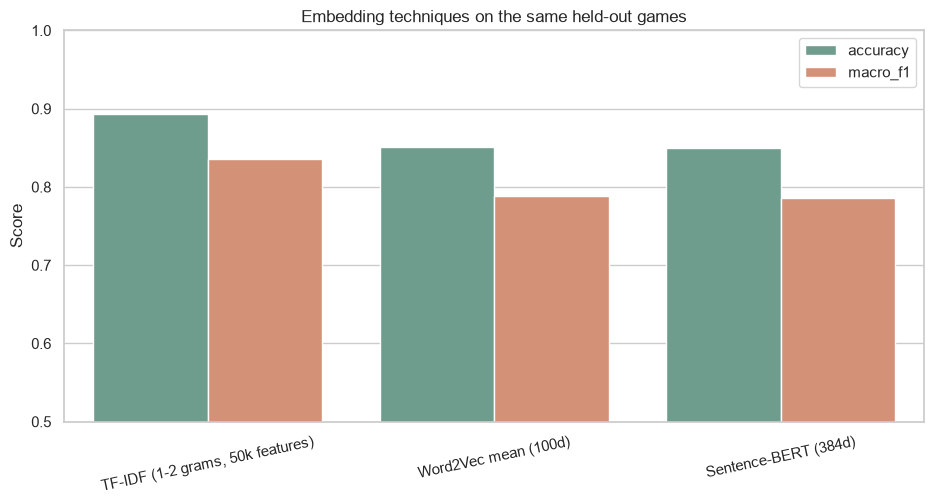

In [6]:
# Collect accuracy, macro-F1 and negative-class F1 for a set of predictions
def score_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "negative_f1": f1_score(y_true, y_pred, pos_label=0),
    }

# Assemble the comparison table across the three representations
comparison = pd.DataFrame([
    {"representation": "TF-IDF (1-2 grams, 50k features)", "input_text": "clean_review", **score_predictions(y_test, tfidf_pred)},
    {"representation": "Word2Vec mean (100d)", "input_text": "clean_review", **score_predictions(y_test, w2v_pred)},
    {"representation": "Sentence-BERT (384d)", "input_text": "model_text", **score_predictions(y_test, sbert_pred)},
])
comparison.to_csv(TABLE_DIR / "embedding_comparison.csv", index=False)
display(comparison.style.format({"accuracy": "{:.3f}", "macro_f1": "{:.3f}", "negative_f1": "{:.3f}"}))

# Bar chart of accuracy and macro-F1 per representation
plot_data = comparison.melt(id_vars="representation", value_vars=["accuracy", "macro_f1"],
                            var_name="metric", value_name="score")
sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.barplot(data=plot_data, x="representation", y="score", hue="metric",
            palette=["#67A58F", "#E28C69"], ax=ax)
ax.set(title="Embedding techniques on the same held-out games", xlabel="", ylabel="Score", ylim=(0.5, 1.0))
ax.tick_params(axis="x", rotation=12)
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "embedding_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

### 5b. Controlled re-check

TF-IDF refitted on `model_text`, the same text Sentence-BERT encodes, so both
representations receive identical input.


In [7]:
# Refit TF-IDF on model_text — the same text Sentence-BERT encodes — so both
# representations receive identical input
tfidf_ctrl = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95,
                             max_features=50_000, sublinear_tf=True, lowercase=True)
X_tr_ctrl = tfidf_ctrl.fit_transform(df.loc[train_idx, "model_text"])
X_te_ctrl = tfidf_ctrl.transform(df.loc[test_idx, "model_text"])

# Same probe as before; only the input text changes
ctrl_probe = LogisticRegression(max_iter=1_000, class_weight="balanced",
                                n_jobs=N_JOBS, random_state=SEED)
ctrl_probe.fit(X_tr_ctrl, y_train)
ctrl_pred = ctrl_probe.predict(X_te_ctrl)

controlled = pd.DataFrame([
    {"representation": "TF-IDF (same text as SBERT)", "input_text": "model_text", **score_predictions(y_test, ctrl_pred)},
    {"representation": "Sentence-BERT (384d)", "input_text": "model_text", **score_predictions(y_test, sbert_pred)},
])
controlled.to_csv(TABLE_DIR / "embedding_comparison_controlled.csv", index=False)
display(controlled.style.format({"accuracy": "{:.3f}", "macro_f1": "{:.3f}", "negative_f1": "{:.3f}"}))

# Free the control matrices
del X_tr_ctrl, X_te_ctrl
gc.collect()

,representation,input_text,accuracy,macro_f1,negative_f1
0,TF-IDF (same text as SBERT),model_text,0.901,0.848,0.759
1,Sentence-BERT (384d),model_text,0.850,0.786,0.670


496

## 6. t-SNE and PCA

t-SNE preserves local neighbourhood structure; PCA gives a global linear view.
A 5,000-review subsample keeps t-SNE tractable.


In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Random 5,000-review subsample for visualisation
viz_idx = df.sample(n=5_000, random_state=SEED).index.to_numpy()
viz_embeddings = embeddings[viz_idx]

# Project to 2D with PCA — a global linear view
pca = PCA(n_components=2, random_state=SEED)
pca_2d = pca.fit_transform(viz_embeddings)

# Project to 2D with t-SNE — preserves local neighbourhood structure
# perplexity ~ size of the neighbourhood each point considers; 40 suits a 5,000-point sample
tsne = TSNE(n_components=2, perplexity=40, init="pca", learning_rate="auto",
            max_iter=1_000, random_state=SEED)
tsne_2d = tsne.fit_transform(viz_embeddings)

# Collect coordinates and labels for plotting
viz = df.loc[viz_idx, ["recommendation", "primary_genre"]].reset_index(drop=True)
viz["tsne_x"], viz["tsne_y"] = tsne_2d[:, 0], tsne_2d[:, 1]
viz["pca_x"], viz["pca_y"] = pca_2d[:, 0], pca_2d[:, 1]

print("PCA variance explained:", pca.explained_variance_ratio_.round(4),
      "total", round(pca.explained_variance_ratio_.sum(), 4))

PCA variance explained: [0.0686 0.0562] total 0.1248


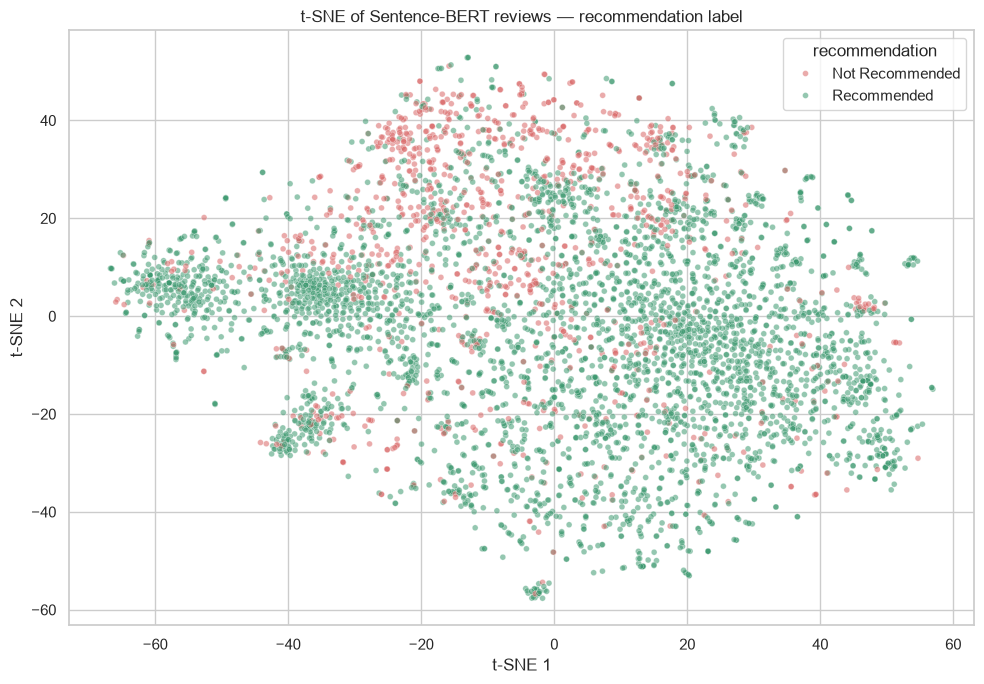

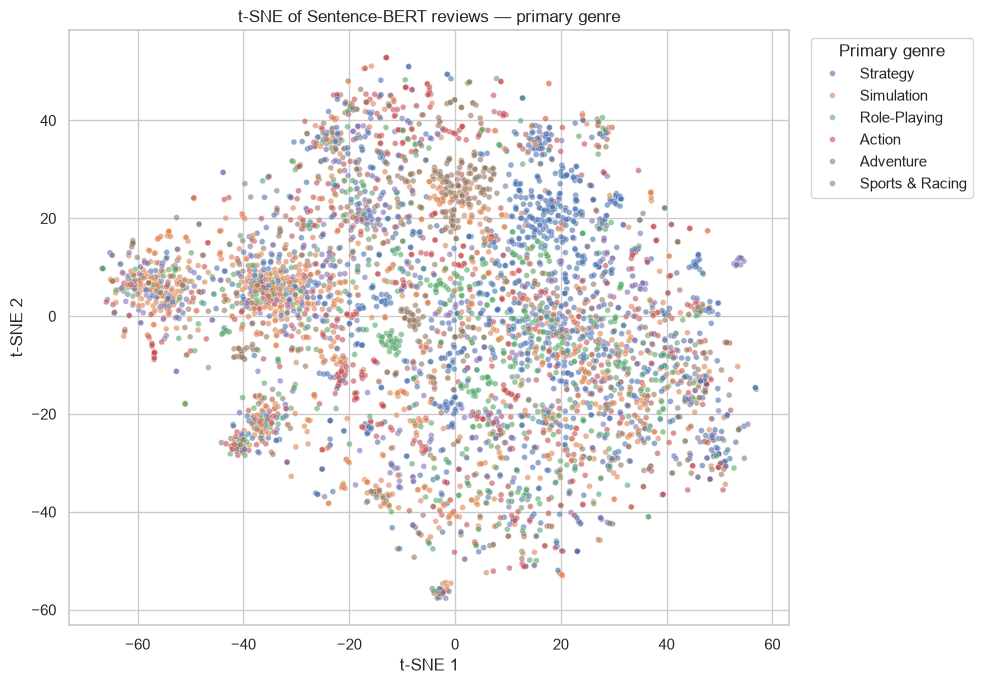

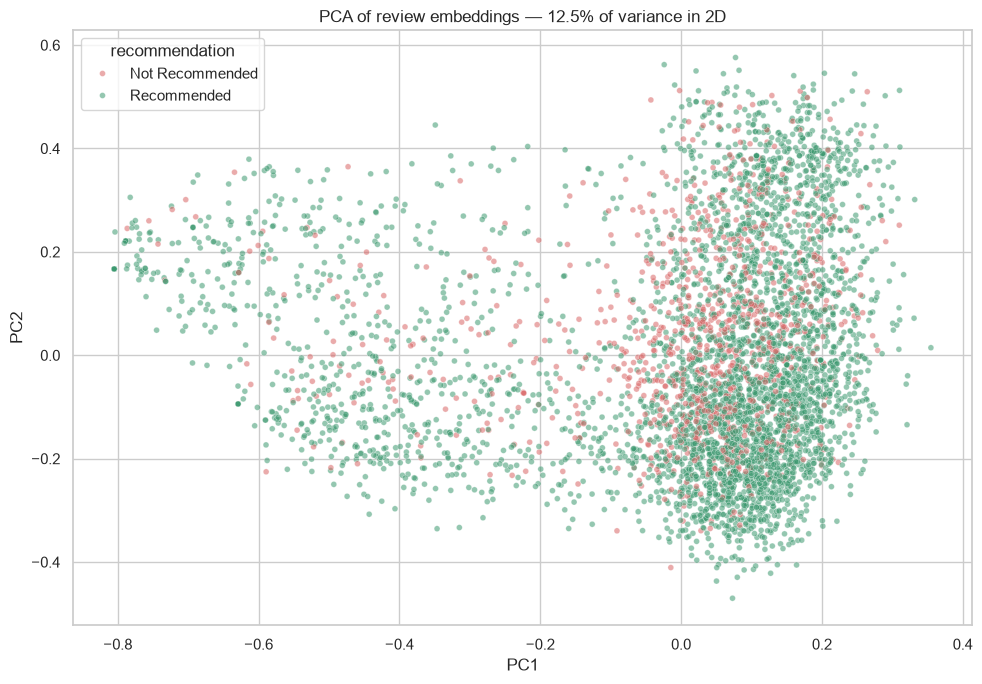

In [9]:
# t-SNE coloured by the recommendation label
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=viz, x="tsne_x", y="tsne_y", hue="recommendation", alpha=0.55, s=18,
                palette={"Recommended": "#3D9970", "Not Recommended": "#D96666"}, ax=ax)
ax.set(title="t-SNE of Sentence-BERT reviews — recommendation label", xlabel="t-SNE 1", ylabel="t-SNE 2")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "tsne_sentiment.png", dpi=180, bbox_inches="tight"); plt.show()

# t-SNE coloured by primary genre (rows without a genre are dropped)
genre_viz = viz.dropna(subset=["primary_genre"])
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=genre_viz, x="tsne_x", y="tsne_y", hue="primary_genre", alpha=0.6, s=18, ax=ax)
ax.set(title="t-SNE of Sentence-BERT reviews — primary genre", xlabel="t-SNE 1", ylabel="t-SNE 2")
ax.legend(title="Primary genre", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "tsne_genre.png", dpi=180, bbox_inches="tight"); plt.show()

# PCA coloured by the recommendation label; the title reports the variance the 2D projection explains
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=viz, x="pca_x", y="pca_y", hue="recommendation", alpha=0.55, s=18,
                palette={"Recommended": "#3D9970", "Not Recommended": "#D96666"}, ax=ax)
ax.set(title=f"PCA of review embeddings — {pca.explained_variance_ratio_.sum():.1%} of variance in 2D",
       xlabel="PC1", ylabel="PC2")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "pca_sentiment.png", dpi=180, bbox_inches="tight"); plt.show()

## 7. Semantic search over reviews

The document-level counterpart of the "N most similar" requirement (notebook 02
covers the word-level version). Because the vectors are normalised, ranking is a
single matrix-vector product. This function is the retrieval core that notebook 05
wraps into the RAG system.


In [10]:
# Embed the query, score every review by dot product (cosine, since vectors are
# normalised), drop very short reviews, and return the top-k with game and verdict
def most_similar_reviews(query, k=5, min_words=20):
    query_vector = sentence_model.encode([query], normalize_embeddings=True,
                                         convert_to_numpy=True)[0]
    scores = embeddings @ query_vector
    eligible = df["word_count"].ge(min_words).to_numpy()
    scores = np.where(eligible, scores, -np.inf)
    best = np.argpartition(scores, -k)[-k:]
    best = best[np.argsort(scores[best])[::-1]]
    result = df.loc[best, ["game_name", "recommendation", "review"]].copy()
    result.insert(0, "similarity", scores[best].round(3))
    result["review"] = result["review"].str.slice(0, 260) + "..."
    return result.reset_index(drop=True)

# Try a few example queries
for query in [
    "an emotional story that stays with you",
    "a relaxing game to play with friends",
    "poor performance and technical problems",
]:
    print("\nQUERY:", query)
    display(most_similar_reviews(query, k=5))


QUERY: an emotional story that stays with you


,similarity,game_name,recommendation,review
0,0.585,FINAL FANTASY XIV Online,Recommended,2021 An intricately woven haunting fairytale w...
1,0.575,Life is Strange - Episode 1,Recommended,2017 RecommendedA beautiful yet heartbreaking ...
2,0.567,It Takes Two,Recommended,Experience an emotional rollercoaster with It ...
3,0.567,It Takes Two Friend's Pass,Recommended,Experience an emotional rollercoaster with It ...
4,0.543,OMORI,Recommended,2021 A wonderful story about a boy and his str...



QUERY: a relaxing game to play with friends


,similarity,game_name,recommendation,review
0,0.745,American Truck Simulator,Recommended,2022 This game is great for relaxing and playi...
1,0.709,PowerWash Simulator,Recommended,This is a really fun game to play when your bo...
2,0.707,Slime Rancher,Recommended,2022 If you're looking for a relaxing game to ...
3,0.704,House Flipper,Recommended,This game is very relaxing and stress free. Iv...
4,0.704,Golf With Your Friends,Recommended,"2023 super fun to play with friends, especiall..."



QUERY: poor performance and technical problems


,similarity,game_name,recommendation,review
0,0.494,Dragon's Dogma 2,Not Recommended,"cannot use items, performance in cities is not..."
1,0.494,Total War: ROME II - Emperor Edition,Not Recommended,2018 Horribly optimized even 5 years after lau...
2,0.486,ELDEN RING,Not Recommended,2022 After patch 1.02.1This patch claims to ad...
3,0.482,The First Descendant,Recommended,The game has potential it has issues like with...
4,0.479,STAR WARS Jedi: Survivor™,Not Recommended,"2023 Terrible performance on a high end PC, no..."


## 8. Save artifacts

Everything downstream needs is under `outputs/`: the embedding matrix and its
row-aligned metadata (read by notebooks 04 and 05), the fitted vectoriser and
probes, and the comparison tables and figures. Results and their interpretation
are discussed in the report.

**Next:** notebook 04 — fine-tuned DistilBERT and SHAP.


In [11]:
# End-of-notebook checks: data, split and saved artifacts are all consistent
assert len(df) == 120_000
assert embeddings.shape == (120_000, 384)
assert np.allclose(np.linalg.norm(embeddings, axis=1), 1.0, atol=1e-3)
assert not (train_games & test_games)
assert len(train_idx) + len(test_idx) == len(df)
assert (EMBEDDING_DIR / "sbert_row_metadata.csv").exists()
assert (TABLE_DIR / "embedding_comparison.csv").exists()
assert (TABLE_DIR / "embedding_comparison_controlled.csv").exists()
print("All embedding and split checks passed.")

All embedding and split checks passed.
